In [382]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlt

In [383]:
greed_df=pd.read_csv("fear_greed_index.csv")            
history_df=pd.read_csv("historical_data.csv")

In [384]:
greed_df

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [385]:
greed_df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [386]:
greed_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [387]:
history_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [388]:
greed_df.dtypes

timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [389]:
history_df.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [390]:
greed_df["date"]=pd.to_datetime(greed_df["date"])

In [391]:
greed_df.dtypes

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object

In [392]:
history_df["Timestamp IST"] = pd.to_datetime(
    history_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [393]:
history_df.dtypes

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST       datetime64[ns]
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
dtype: object

In [394]:
history_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [395]:

history_df['date'] = history_df['Timestamp IST'].dt.normalize()


In [396]:
history_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25


In [397]:
greed_df["timestamp"] = pd.to_datetime(
    greed_df["timestamp"],
    unit="s"
)

In [398]:
greed_df

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,2025-04-28 05:30:00,54,Neutral,2025-04-28
2640,2025-04-29 05:30:00,60,Greed,2025-04-29
2641,2025-04-30 05:30:00,56,Greed,2025-04-30
2642,2025-05-01 05:30:00,53,Neutral,2025-05-01


In [399]:
greed_df = greed_df.drop(columns=["timestamp"])

In [400]:
greed_df

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05
...,...,...,...
2639,54,Neutral,2025-04-28
2640,60,Greed,2025-04-29
2641,56,Greed,2025-04-30
2642,53,Neutral,2025-05-01


In [401]:
history_df=history_df.drop(columns=["Account","Transaction Hash","Order ID","Trade ID","Timestamp IST"])

In [402]:
history_df

,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp,date
0,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,1.730000e+12,2024-12-02
1,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,1.730000e+12,2024-12-02
2,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,1.730000e+12,2024-12-02
3,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,1.730000e+12,2024-12-02
4,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,1.730000e+12,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...
211219,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,1.750000e+12,2025-04-25
211220,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,1.750000e+12,2025-04-25
211221,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,1.750000e+12,2025-04-25
211222,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,1.750000e+12,2025-04-25


In [403]:
print(history_df.dtypes)
print(greed_df.dtypes)

Coin                       object
Execution Price           float64
Size Tokens               float64
Size USD                  float64
Side                       object
Start Position            float64
Direction                  object
Closed PnL                float64
Crossed                      bool
Fee                       float64
Timestamp                 float64
date               datetime64[ns]
dtype: object
value                      int64
classification            object
date              datetime64[ns]
dtype: object


In [404]:
merged_df=pd.merge(greed_df,history_df,on="date",how="inner")

In [405]:
merged_df

,value,classification,date,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp
0,63,Greed,2023-05-01,ETH,1897.9,0.0967,183.53,BUY,0.0000,Open Long,0.0,True,0.000000,1.680000e+12
1,63,Greed,2023-05-01,ETH,1897.9,0.0824,156.39,BUY,0.0967,Open Long,0.0,True,0.000000,1.680000e+12
2,63,Greed,2023-05-01,ETH,1898.6,0.0722,137.08,BUY,0.1791,Open Long,0.0,True,0.000000,1.680000e+12
3,75,Extreme Greed,2023-12-05,ETH,2230.1,0.4933,1100.11,BUY,0.0000,Open Long,0.0,True,0.275027,1.700000e+12
4,75,Extreme Greed,2023-12-05,ETH,2230.1,0.8681,1935.95,BUY,0.4933,Open Long,0.0,True,0.483987,1.700000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,53,Neutral,2025-05-01,ETH,1805.6,2.5000,4514.00,SELL,-473.9880,Open Short,0.0,True,1.579900,1.750000e+12
211214,53,Neutral,2025-05-01,ETH,1805.6,5.0000,9028.00,SELL,-476.4880,Open Short,0.0,True,3.159800,1.750000e+12
211215,53,Neutral,2025-05-01,ETH,1805.6,8.8000,15889.28,SELL,-481.4880,Open Short,0.0,True,5.561248,1.750000e+12
211216,53,Neutral,2025-05-01,ETH,1805.6,14.1217,25498.14,SELL,-490.2880,Open Short,0.0,True,8.924349,1.750000e+12


In [406]:
print('Shape: ',merged_df.shape)

Shape:  (211218, 14)


In [407]:
numeric_df = merged_df.select_dtypes(include=['int64', 'float64'])

In [408]:
numeric_df

,value,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Fee,Timestamp
0,63,1897.9,0.0967,183.53,0.0000,0.0,0.000000,1.680000e+12
1,63,1897.9,0.0824,156.39,0.0967,0.0,0.000000,1.680000e+12
2,63,1898.6,0.0722,137.08,0.1791,0.0,0.000000,1.680000e+12
3,75,2230.1,0.4933,1100.11,0.0000,0.0,0.275027,1.700000e+12
4,75,2230.1,0.8681,1935.95,0.4933,0.0,0.483987,1.700000e+12
...,...,...,...,...,...,...,...,...
211213,53,1805.6,2.5000,4514.00,-473.9880,0.0,1.579900,1.750000e+12
211214,53,1805.6,5.0000,9028.00,-476.4880,0.0,3.159800,1.750000e+12
211215,53,1805.6,8.8000,15889.28,-481.4880,0.0,5.561248,1.750000e+12
211216,53,1805.6,14.1217,25498.14,-490.2880,0.0,8.924349,1.750000e+12


In [409]:
corr_matrix = numeric_df.corr()
print(corr_matrix)

                    value  Execution Price  ...       Fee  Timestamp
value            1.000000        -0.027558  ... -0.026877  -0.377565
Execution Price -0.027558         1.000000  ...  0.225266   0.130706
Size Tokens      0.023080        -0.017185  ...  0.006710  -0.040949
Size USD        -0.029843         0.189859  ...  0.745940   0.039762
Start Position  -0.049619         0.017242  ...  0.010559  -0.105488
Closed PnL       0.008121        -0.006429  ...  0.084094  -0.009564
Fee             -0.026877         0.225266  ...  1.000000   0.036890
Timestamp       -0.377565         0.130706  ...  0.036890   1.000000

[8 rows x 8 columns]


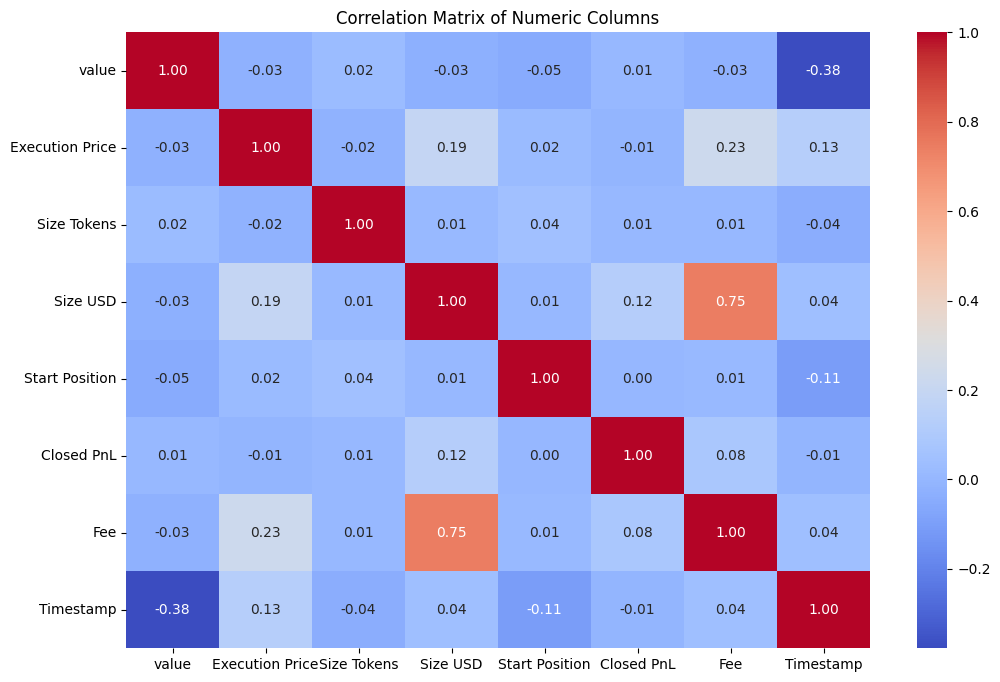

In [410]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Columns")
plt.show()

In [411]:
risk_appetite_summary = merged_df.groupby('classification').agg(
    avg_trade_size=('Size USD', 'mean'),
    median_trade_size=('Size USD', 'median'),
    trade_count=('Size USD', 'count')
).reset_index()

print(risk_appetite_summary.round(3))

  classification  avg_trade_size  median_trade_size  trade_count
0   Extreme Fear        5349.732            766.150        21400
1  Extreme Greed        3112.252            500.050        39992
2           Fear        7816.110            735.960        61837
3          Greed        5736.884            555.000        50303
4        Neutral        4782.733            547.655        37686


In [412]:
merged_df.columns = merged_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [413]:
merged_df

,value,classification,date,coin,execution_price,size_tokens,size_usd,side,start_position,direction,closed_pnl,crossed,fee,timestamp
0,63,Greed,2023-05-01,ETH,1897.9,0.0967,183.53,BUY,0.0000,Open Long,0.0,True,0.000000,1.680000e+12
1,63,Greed,2023-05-01,ETH,1897.9,0.0824,156.39,BUY,0.0967,Open Long,0.0,True,0.000000,1.680000e+12
2,63,Greed,2023-05-01,ETH,1898.6,0.0722,137.08,BUY,0.1791,Open Long,0.0,True,0.000000,1.680000e+12
3,75,Extreme Greed,2023-12-05,ETH,2230.1,0.4933,1100.11,BUY,0.0000,Open Long,0.0,True,0.275027,1.700000e+12
4,75,Extreme Greed,2023-12-05,ETH,2230.1,0.8681,1935.95,BUY,0.4933,Open Long,0.0,True,0.483987,1.700000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,53,Neutral,2025-05-01,ETH,1805.6,2.5000,4514.00,SELL,-473.9880,Open Short,0.0,True,1.579900,1.750000e+12
211214,53,Neutral,2025-05-01,ETH,1805.6,5.0000,9028.00,SELL,-476.4880,Open Short,0.0,True,3.159800,1.750000e+12
211215,53,Neutral,2025-05-01,ETH,1805.6,8.8000,15889.28,SELL,-481.4880,Open Short,0.0,True,5.561248,1.750000e+12
211216,53,Neutral,2025-05-01,ETH,1805.6,14.1217,25498.14,SELL,-490.2880,Open Short,0.0,True,8.924349,1.750000e+12


  classification  avg_trade_size  median_trade_size  trade_count
0   Extreme Fear        5349.732            766.150        21400
1  Extreme Greed        3112.252            500.050        39992
2           Fear        7816.110            735.960        61837
3          Greed        5736.884            555.000        50303
4        Neutral        4782.733            547.655        37686


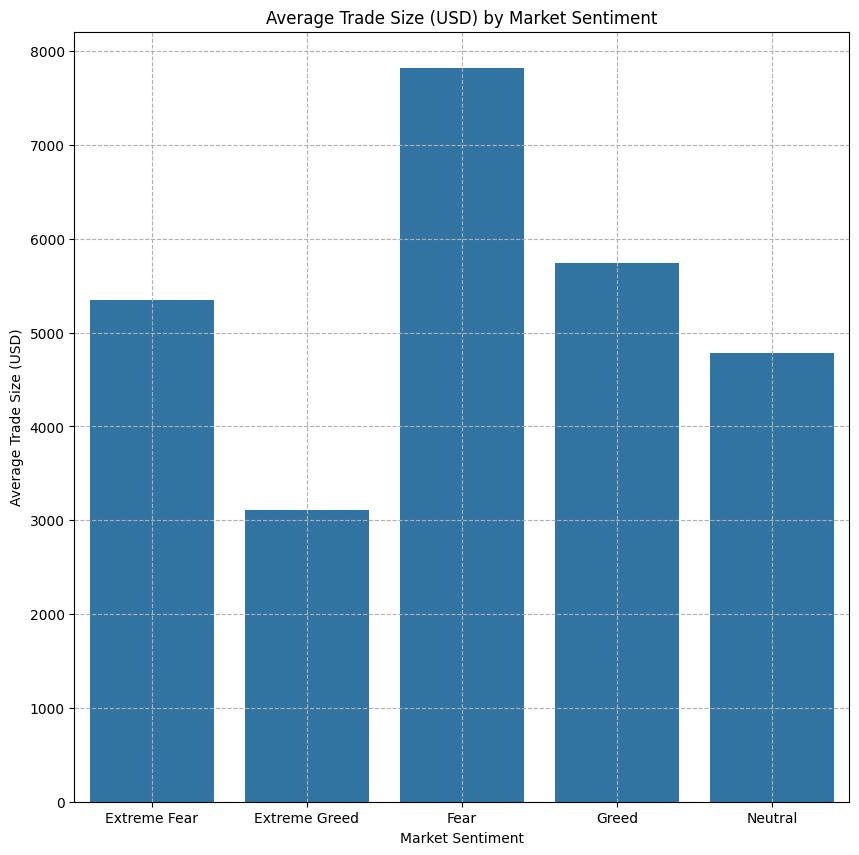

In [414]:
print(risk_appetite_summary.round(3))

# Plot average trade size by sentiment
plt.figure(figsize=(10,10))
sns.barplot(data=risk_appetite_summary, x='classification', y='avg_trade_size')
plt.title('Average Trade Size (USD) by Market Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xlabel('Market Sentiment')
plt.grid(True, linestyle='--')
plt.savefig('Average_trade_size.png',dpi = 300, bbox_inches = 'tight')
plt.show()

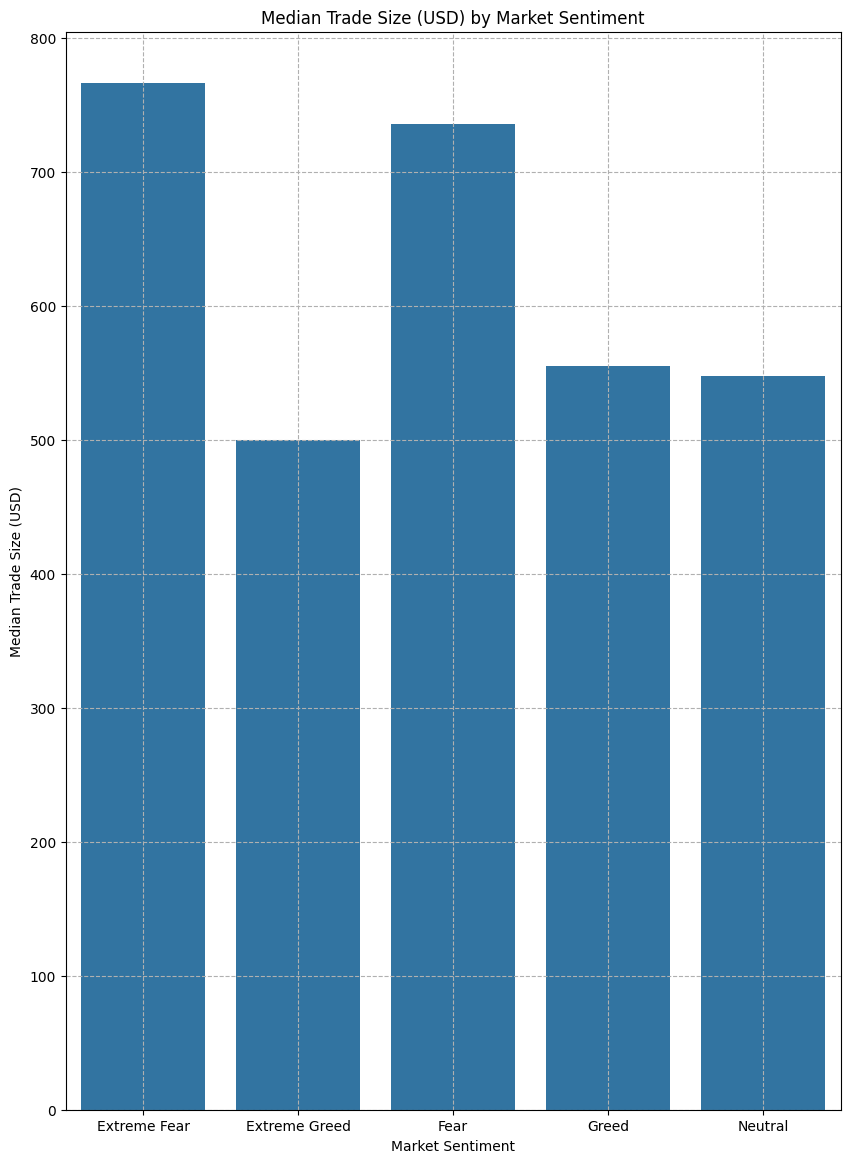

In [415]:

# Plot median trade size by sentiment
plt.figure(figsize=(10,14))
sns.barplot(data=risk_appetite_summary, x='classification', y='median_trade_size')
plt.title('Median Trade Size (USD) by Market Sentiment')
plt.ylabel('Median Trade Size (USD)')
plt.xlabel('Market Sentiment')
plt.grid(True, linestyle='--')
plt.savefig('Median_trade_size.png',dpi = 300, bbox_inches = 'tight')
plt.show()

In [416]:
# Normalize column names: lowercase, strip spaces, replace spaces with underscores
merged_df.columns = merged_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [417]:
merged_df

,value,classification,date,coin,execution_price,size_tokens,size_usd,side,start_position,direction,closed_pnl,crossed,fee,timestamp
0,63,Greed,2023-05-01,ETH,1897.9,0.0967,183.53,BUY,0.0000,Open Long,0.0,True,0.000000,1.680000e+12
1,63,Greed,2023-05-01,ETH,1897.9,0.0824,156.39,BUY,0.0967,Open Long,0.0,True,0.000000,1.680000e+12
2,63,Greed,2023-05-01,ETH,1898.6,0.0722,137.08,BUY,0.1791,Open Long,0.0,True,0.000000,1.680000e+12
3,75,Extreme Greed,2023-12-05,ETH,2230.1,0.4933,1100.11,BUY,0.0000,Open Long,0.0,True,0.275027,1.700000e+12
4,75,Extreme Greed,2023-12-05,ETH,2230.1,0.8681,1935.95,BUY,0.4933,Open Long,0.0,True,0.483987,1.700000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,53,Neutral,2025-05-01,ETH,1805.6,2.5000,4514.00,SELL,-473.9880,Open Short,0.0,True,1.579900,1.750000e+12
211214,53,Neutral,2025-05-01,ETH,1805.6,5.0000,9028.00,SELL,-476.4880,Open Short,0.0,True,3.159800,1.750000e+12
211215,53,Neutral,2025-05-01,ETH,1805.6,8.8000,15889.28,SELL,-481.4880,Open Short,0.0,True,5.561248,1.750000e+12
211216,53,Neutral,2025-05-01,ETH,1805.6,14.1217,25498.14,SELL,-490.2880,Open Short,0.0,True,8.924349,1.750000e+12


In [ ]:
# Rename columns for clarity
merged_df.rename(columns={
    'value': 'trader_id'   ,
    'coin': 'asset_traded',
    'execution_price': 'trade_price',
    'size_tokens': 'amount_traded',
    'size_usd': 'trade_usd',
    'closed_pnl': 'profit_loss',
    'timestamp': 'trade_timestamp'
}, inplace=True)

# Optional: normalize all column names to lowercase with underscores (safe for groupby & plotting)
merged_df.columns = merged_df.columns.str.strip().str.lower().str.replace(' ', '_')

# Verify
print(merged_df.head())

   trader_id classification       date  ... crossed       fee  trade_timestamp
0         63          Greed 2023-05-01  ...    True  0.000000     1.680000e+12
1         63          Greed 2023-05-01  ...    True  0.000000     1.680000e+12
2         63          Greed 2023-05-01  ...    True  0.000000     1.680000e+12
3         75  Extreme Greed 2023-12-05  ...    True  0.275027     1.700000e+12
4         75  Extreme Greed 2023-12-05  ...    True  0.483987     1.700000e+12

[5 rows x 14 columns]


In [419]:
merged_df

,trader_id,classification,date,asset_traded,trade_price,amount_traded,trade_usd,side,start_position,direction,profit_loss,crossed,fee,trade_timestamp
0,63,Greed,2023-05-01,ETH,1897.9,0.0967,183.53,BUY,0.0000,Open Long,0.0,True,0.000000,1.680000e+12
1,63,Greed,2023-05-01,ETH,1897.9,0.0824,156.39,BUY,0.0967,Open Long,0.0,True,0.000000,1.680000e+12
2,63,Greed,2023-05-01,ETH,1898.6,0.0722,137.08,BUY,0.1791,Open Long,0.0,True,0.000000,1.680000e+12
3,75,Extreme Greed,2023-12-05,ETH,2230.1,0.4933,1100.11,BUY,0.0000,Open Long,0.0,True,0.275027,1.700000e+12
4,75,Extreme Greed,2023-12-05,ETH,2230.1,0.8681,1935.95,BUY,0.4933,Open Long,0.0,True,0.483987,1.700000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,53,Neutral,2025-05-01,ETH,1805.6,2.5000,4514.00,SELL,-473.9880,Open Short,0.0,True,1.579900,1.750000e+12
211214,53,Neutral,2025-05-01,ETH,1805.6,5.0000,9028.00,SELL,-476.4880,Open Short,0.0,True,3.159800,1.750000e+12
211215,53,Neutral,2025-05-01,ETH,1805.6,8.8000,15889.28,SELL,-481.4880,Open Short,0.0,True,5.561248,1.750000e+12
211216,53,Neutral,2025-05-01,ETH,1805.6,14.1217,25498.14,SELL,-490.2880,Open Short,0.0,True,8.924349,1.750000e+12


In [420]:
merged_df['trade_timestamp'] = pd.to_datetime(merged_df['trade_timestamp'], unit='ms', errors='coerce')
merged_df['date'] = merged_df['trade_timestamp'].dt.date  # extract just the date

In [422]:
print(merged_df.columns.tolist())

['trader_id', 'classification', 'date', 'asset_traded', 'trade_price', 'amount_traded', 'trade_usd', 'side', 'start_position', 'direction', 'profit_loss', 'crossed', 'fee', 'trade_timestamp']


In [425]:
# Remove leading/trailing spaces and tabs from all column names
merged_df.columns = merged_df.columns.str.strip()

# Optional: lowercase and replace spaces with underscores for safety
merged_df.columns = merged_df.columns.str.lower().str.replace(' ', '_')

print(merged_df.columns.tolist())  # Check the cleaned names

['trader_id', 'classification', 'date', 'asset_traded', 'trade_price', 'amount_traded', 'trade_usd', 'side', 'start_position', 'direction', 'profit_loss', 'crossed', 'fee', 'trade_timestamp']


In [428]:
merged_df["profitable"]=(merged_df["profit_loss"]>0).astype(float)

In [ ]:
daily_summary = merged_df.groupby(['trader_id', 'date']).agg(
    total_trade_usd=('trade_usd', 'sum'),
    avg_trade_usd=('trade_usd', 'mean'),
    total_profit_loss=('profit_loss', 'sum'),
    avg_profit_loss=('profit_loss', 'mean'),
    trade_count=('trade_usd', 'count'),
    win_rate=('profitable', 'mean') 
).reset_index()

In [430]:
daily_summary

,trader_id,date,total_trade_usd,avg_trade_usd,total_profit_loss,avg_profit_loss,trade_count,win_rate
0,10,2025-02-19,1999898.43,2247.076888,-36525.167517,-41.039514,890,0.277528
1,15,2025-02-19,11124247.15,4631.243609,182075.566585,75.801651,2402,0.253539
2,16,2025-02-19,4123660.77,4046.772100,225628.108748,221.421108,1019,0.388616
3,17,2024-07-03,61478.38,574.564299,267.318048,2.498300,107,0.121495
4,18,2025-02-19,28556806.47,7198.589985,43120.444797,10.869787,3967,0.430552
...,...,...,...,...,...,...,...,...
190,88,2024-10-27,1008361.81,9166.925545,4563.509225,41.486447,110,0.254545
191,90,2024-03-09,841810.32,4676.724000,19791.026041,109.950145,180,0.905556
192,90,2024-10-27,1844018.72,3587.585058,3841.244276,7.473238,514,0.387160
193,93,2024-10-27,516245.68,1422.164408,2901.531638,7.993200,363,0.352617
